# Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset 

In [22]:
df = pd.read_csv("/kaggle/input/datasets/tanayatipre/store-sales-forecasting-dataset/stores_sales_forecasting.csv",
                encoding ="Latin1")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028


In [23]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [24]:
df.describe

<bound method NDFrame.describe of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
3          6  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
4         11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
...      ...             ...         ...         ...             ...   
2116    9963  CA-2015-168088   3/19/2015   3/22/2015     First Class   
2117    9965  CA-2016-146374   12/5/2016  12/10/2016    Second Class   
2118    9981  US-2015-151435    9/6/2015    9/9/2015    Second Class   
2119    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
2120    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   

     Customer ID     Customer Name      Segment        Country  \
0       CG-12520       Claire Gute 

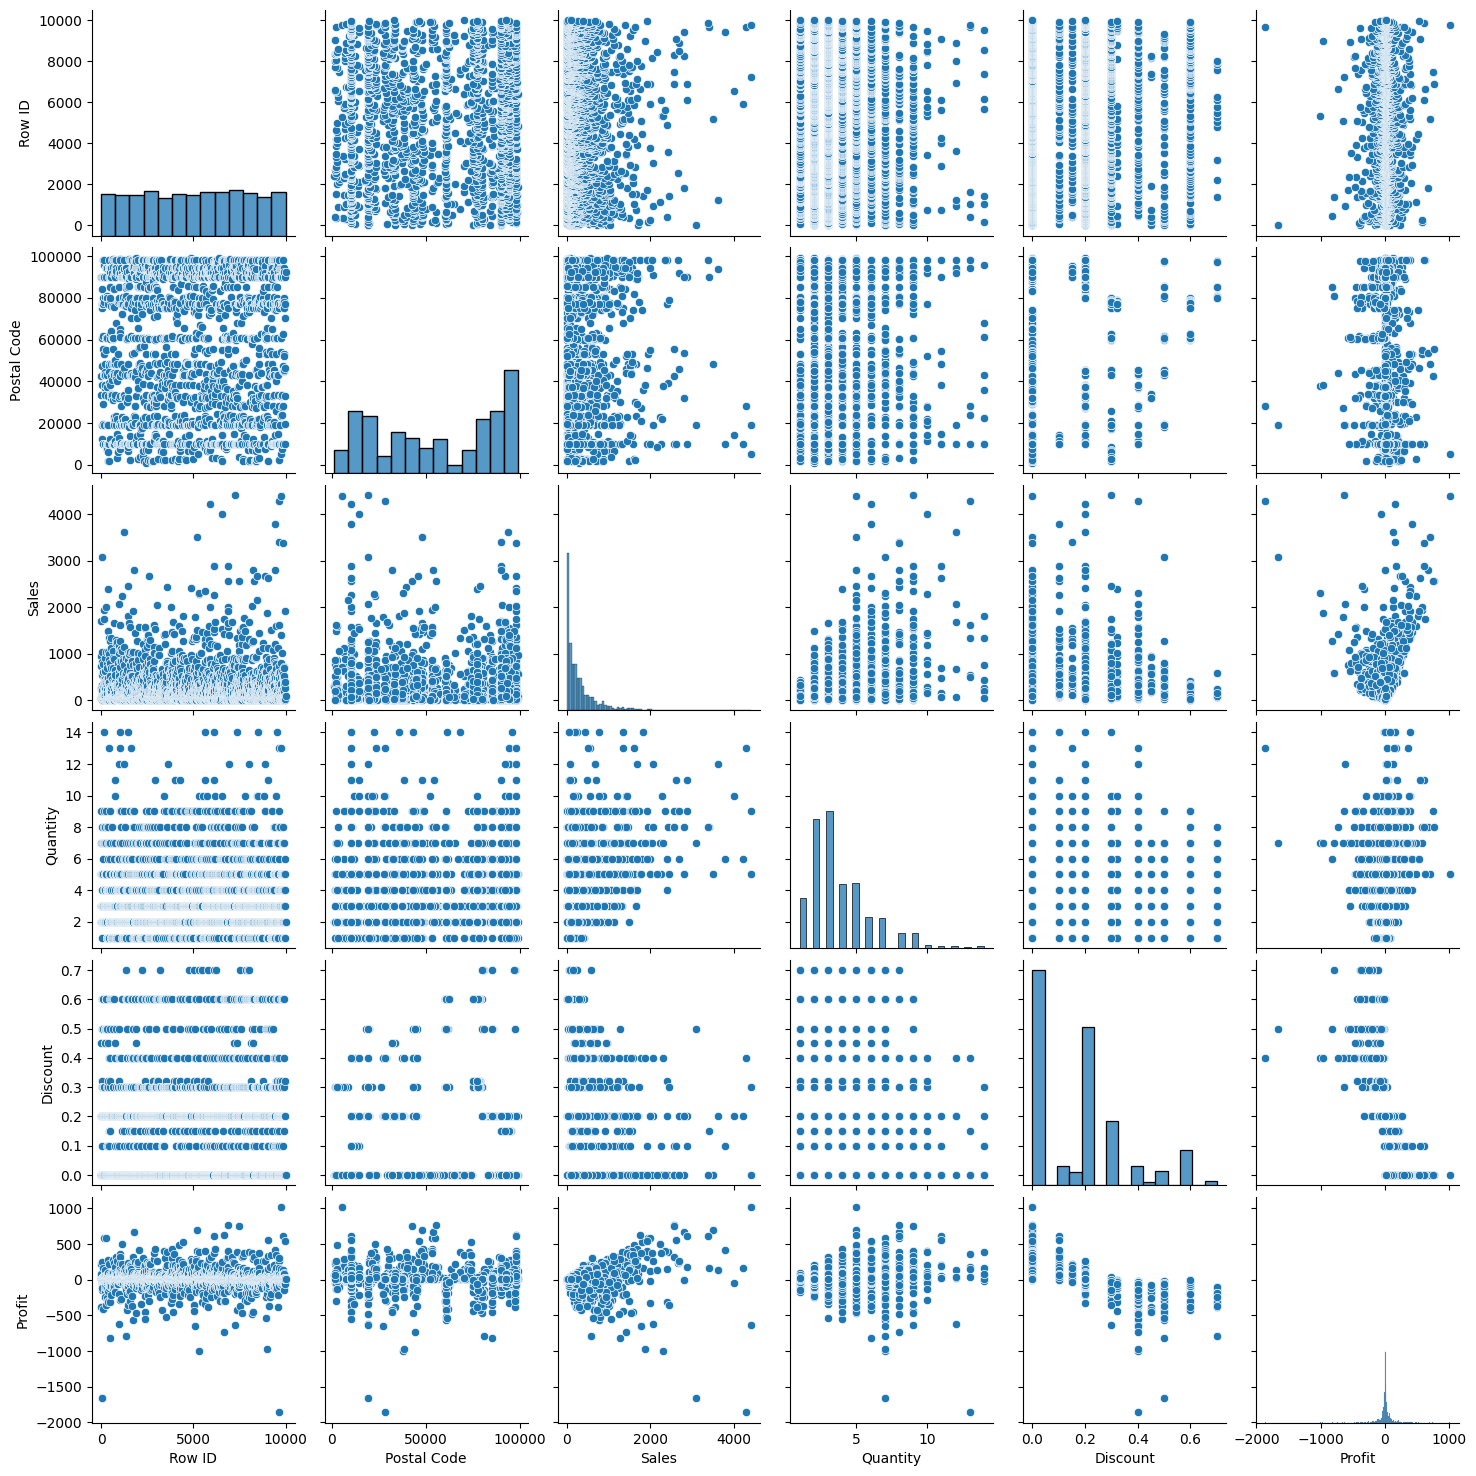

In [25]:
sns.pairplot(df)

# Data Preprocessing

In [26]:
# ==============================
# 1. Separate Features & Target
# ==============================
TARGET_COL = 'Sales'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [27]:
# ==============================
# 2. One-Hot Encode ALL Categorical FEATURES
# ==============================
cat_cols = X.select_dtypes(include='object').columns

X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

In [28]:
# ==============================
# 3. Encode Target Variable - Label Encoding
# ==============================

le = LabelEncoder()
y = le.fit_transform(y)

In [29]:
# ==============================
# 4. Feature Scaling (Standardization)
# ==============================
scaler = StandardScaler()
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = scaler.fit_transform(X[num_cols])

In [30]:
# 6. Final Output
# ==============================
print("Final Feature Shape:", X.shape)
print("Target Shape:", y.shape)

X.head(), y[:5]

Final Feature Shape: (2121, 6208)
Target Shape: (2121,)


(     Row ID  Postal Code  Quantity  Discount    Profit  \
 0 -1.747154    -0.412552 -0.792953 -0.958228  0.244192   
 1 -1.746807    -0.412552 -0.348723 -0.958228  1.550412   
 2 -1.746114    -0.694964  0.539736  1.521050 -2.880006   
 3 -1.745421     1.063593  1.428194 -0.958228  0.040216   
 4 -1.743688     1.063593  2.316653  0.143673  0.563237   
 
    Order ID_CA-2014-100678  Order ID_CA-2014-100706  Order ID_CA-2014-100916  \
 0                    False                    False                    False   
 1                    False                    False                    False   
 2                    False                    False                    False   
 3                    False                    False                    False   
 4                    False                    False                    False   
 
    Order ID_CA-2014-101462  Order ID_CA-2014-101560  ...  \
 0                    False                    False  ...   
 1                    False       

# Train-Test Split

In [31]:
# -------------------------------
# Train-Test Split
# -------------------------------
# 20% test size, random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
)

# -------------------------------
# Inspect first few rows
# -------------------------------
print("X_train head:\n", X_train.head())
print("\ny_train first 5 values:\n", y_train[:5])

X_train head:
         Row ID  Postal Code  Quantity  Discount    Profit  \
1975  1.485361     1.311437  0.095506 -0.958228  0.191987   
1569  0.831649     1.064121 -0.792953  0.143673 -0.085695   
767  -0.465725     1.314196 -0.792953 -0.958228  0.103033   
1584  0.856258    -0.387470  0.539736  0.143673  1.030353   
869  -0.302470     1.096829 -0.792953  0.143673 -0.542097   

      Order ID_CA-2014-100678  Order ID_CA-2014-100706  \
1975                    False                    False   
1569                    False                    False   
767                     False                    False   
1584                    False                    False   
869                     False                    False   

      Order ID_CA-2014-100916  Order ID_CA-2014-101462  \
1975                    False                    False   
1569                    False                    False   
767                     False                    False   
1584                    False        

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n📊 Model Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)



📊 Model Performance:
MAE: 45626.38864301699
MSE: 3679361428.133078
RMSE: 60657.74005131644
R2 Score: -16981.205871262806


# Visualization

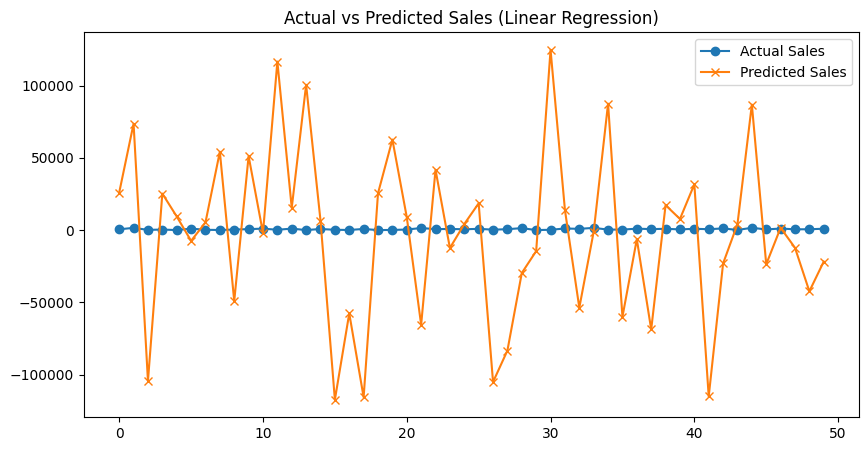

In [32]:
plt.figure(figsize=(10,5))

plt.plot(y_test[:50], label="Actual Sales", marker='o')
plt.plot(y_pred[:50], label="Predicted Sales", marker='x')

plt.title("Actual vs Predicted Sales (Linear Regression)")
plt.legend()
plt.show()

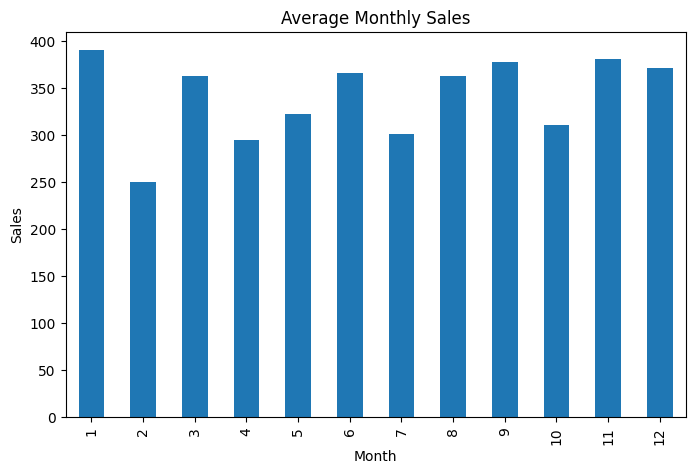

In [33]:
import matplotlib.pyplot as plt

# Create Month column from Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month

# Monthly sales trend
monthly_sales = df.groupby('Month')['Sales'].mean()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar')

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

# Model Training

In [34]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

# Correlation Heatmap

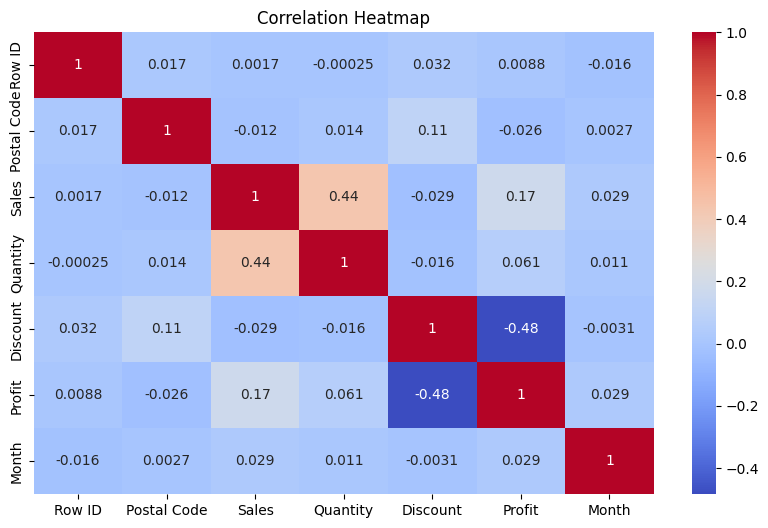

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()